Гипотеза 3: Создание новых признаков.

Цель: создание новых признаков, отражающих финансовую нагрузку заемщика через отношения ключевых финансовых показателей.
credit_to_income: Отношение суммы кредита к годовому доходу (amt_credit / amt_income_total)
annuity_to_income: Отношение аннуитетного платежа к годовому доходу (amt_annuity / amt_income_total)

In [1]:
import pandas as pd
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import LabelEncoder

In [2]:
df_train = pd.read_csv('train_final_processed.csv')
df_test = pd.read_csv('test_final_processed.csv')
print(f"Размер тренировочных данных: {df_train.shape}")
print(f"Размер тестовых данных: {df_test.shape}")

Размер тренировочных данных: (307511, 571)
Размер тестовых данных: (48744, 570)


In [3]:
X_train_full = df_train.drop(['sk_id_curr', 'target'], axis=1)
y_train_full = df_train['target']

In [4]:
if y_train_full.dtype == 'object' or len(y_train_full.unique()) > 2:
    y_train_full = y_train_full.map({'0': 0, '1': 1}).fillna(0).astype(int)

In [5]:
common_cols = X_train_full.columns.intersection(df_test.drop(['sk_id_curr'], axis=1).columns)
if len(common_cols) < 10:
    print("Предупреждение")
X_train_full = X_train_full[common_cols]
df_test_processed = df_test[common_cols]

In [6]:
cat_cols = [col for col in common_cols if X_train_full[col].dtype == 'object']
label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    X_train_full[col] = X_train_full[col].astype(str).fillna('missing')
    df_test_processed[col] = df_test_processed[col].astype(str).fillna('missing')
    
    all_values = pd.concat([X_train_full[col], df_test_processed[col]], axis=0).unique()
    le.fit(all_values) 
    
    X_train_full[col] = le.transform(X_train_full[col])
    df_test_processed[col] = le.transform(df_test_processed[col])

C:\Users\klmv0\AppData\Local\Temp\ipykernel_2792\1254183696.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test_processed[col] = df_test_processed[col].astype(str).fillna('missing')
C:\Users\klmv0\AppData\Local\Temp\ipykernel_2792\1254183696.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test_processed[col] = le.transform(df_test_processed[col])
C:\Users\klmv0\AppData\Local\Temp\ipykernel_2792\1254183696.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a 

In [7]:
for col in X_train_full.columns:
    X_train_full[col] = pd.to_numeric(X_train_full[col], errors='coerce')
    df_test_processed[col] = pd.to_numeric(df_test_processed[col], errors='coerce')

for col in X_train_full.columns:
    if X_train_full[col].dtype in ['float64', 'int64']:
        X_train_full[col].fillna(X_train_full[col].median(), inplace=True)
        df_test_processed[col].fillna(X_train_full[col].median(), inplace=True)

C:\Users\klmv0\AppData\Local\Temp\ipykernel_2792\1661528756.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test_processed[col] = pd.to_numeric(df_test_processed[col], errors='coerce')
C:\Users\klmv0\AppData\Local\Temp\ipykernel_2792\1661528756.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test_processed[col].fillna(X_train_full[col].median(), inplace=True)
C:\Users\klmv0\AppData\Local\Temp\ipykernel_2792\1661528756.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentatio

In [ ]:
required_cols = ['amt_credit', 'amt_income_total', 'amt_annuity']
missing_cols = [col for col in required_cols if col not in common_cols]
if missing_cols:
    print(f"Предупреждение: Отсутствуют столбцы: {missing_cols}. Используем доступные.")
if 'amt_income_total' in common_cols and X_train_full['amt_income_total'].notna().any():
    X_train_full['credit_to_income'] = X_train_full['amt_credit'] / X_train_full['amt_income_total']
    df_test_processed['credit_to_income'] = df_test_processed['amt_credit'] / df_test_processed['amt_income_total']
if 'amt_annuity' in common_cols and 'amt_income_total' in common_cols and X_train_full['amt_income_total'].notna().any():
    X_train_full['annuity_to_income'] = X_train_full['amt_annuity'] / X_train_full['amt_income_total']
    df_test_processed['annuity_to_income'] = df_test_processed['amt_annuity'] / df_test_processed['amt_income_total']

X_train_full = X_train_full.fillna(0)
df_test_processed = df_test_processed.fillna(0)

C:\Users\klmv0\AppData\Local\Temp\ipykernel_6328\3819407703.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_train_full['credit_to_income'] = X_train_full['amt_credit'] / X_train_full['amt_income_total']
C:\Users\klmv0\AppData\Local\Temp\ipykernel_6328\3819407703.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_test_processed['credit_to_income'] = df_test_processed['amt_credit'] / df_test_processed['amt_income_total']
C:\Users\klmv0\AppData\Local\Temp\ipykernel_6328\3819407703.py:9: PerformanceWarning: DataFrame is hi

In [42]:
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full)

In [43]:
cat_model_optimal = CatBoostClassifier(
    iterations=1000,     
    learning_rate=0.03,       
    depth=7,          
    auto_class_weights='SqrtBalanced',
    random_state=42,
    l2_leaf_reg=2,  
    eval_metric='AUC',
    loss_function='Logloss',
    verbose=100)

cat_model_optimal.fit(X_train, y_train, eval_set=(X_val, y_val), cat_features=cat_cols)

0:	test: 0.7079805	best: 0.7079805 (0)	total: 2.79s	remaining: 46m 22s
100:	test: 0.7634210	best: 0.7634210 (100)	total: 1m 57s	remaining: 17m 28s
200:	test: 0.7741111	best: 0.7741111 (200)	total: 3m 44s	remaining: 14m 50s
300:	test: 0.7781641	best: 0.7781641 (300)	total: 5m 33s	remaining: 12m 53s
400:	test: 0.7808177	best: 0.7808177 (400)	total: 7m 26s	remaining: 11m 7s
500:	test: 0.7836871	best: 0.7836871 (500)	total: 9m 16s	remaining: 9m 13s
600:	test: 0.7854868	best: 0.7854950 (599)	total: 11m 9s	remaining: 7m 24s
700:	test: 0.7865185	best: 0.7865417 (699)	total: 12m 57s	remaining: 5m 31s
800:	test: 0.7869653	best: 0.7870053 (792)	total: 14m 45s	remaining: 3m 40s
900:	test: 0.7874451	best: 0.7874451 (900)	total: 16m 39s	remaining: 1m 49s
999:	test: 0.7878325	best: 0.7878544 (992)	total: 18m 40s	remaining: 0us

bestTest = 0.7878544092
bestIteration = 992

Shrink model to first 993 iterations.


In [44]:
y_val_pred_proba = cat_model_optimal.predict_proba(X_val)[:, 1]
val_metrics = {
    'ROC-AUC': roc_auc_score(y_val, y_val_pred_proba),
    'Accuracy': accuracy_score(y_val, y_val_pred_proba > 0.5),
    'Precision': precision_score(y_val, y_val_pred_proba > 0.5),
    'Recall': recall_score(y_val, y_val_pred_proba > 0.5),
    'F1-Score': f1_score(y_val, y_val_pred_proba > 0.5)
}
for metric, value in val_metrics.items():
    print(f'Validation {metric}: {value:.4f}')

Validation ROC-AUC: 0.7879
Validation Accuracy: 0.9042
Validation Precision: 0.3674
Validation Recall: 0.2582
Validation F1-Score: 0.3033


In [45]:
test_pred_proba = cat_model_optimal.predict_proba(df_test_processed)[:, 1]
submission = pd.DataFrame({
    'sk_id_curr': df_test['sk_id_curr'],
    'target': test_pred_proba
})
submission.to_csv('submission_baseline_3_1.csv', index=False)

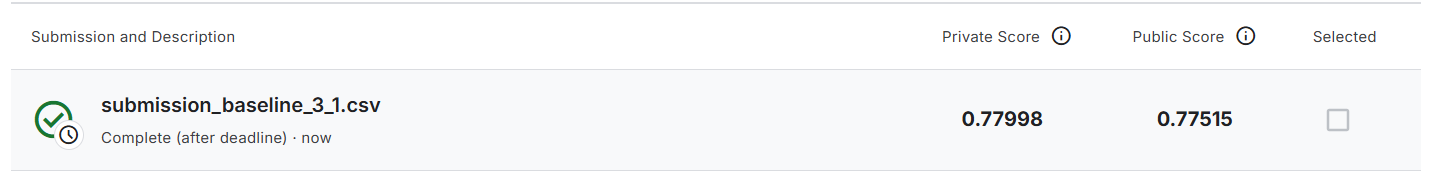

Видим, что поднялся public_score и private_score. Попробуем еще поработать над данной гипезой, чтобы повысить еще качество модели

Добавление новых признаков.

In [32]:
required_cols = ['days_birth', 'days_employed']
missing_cols = [col for col in required_cols if col not in common_cols]
if 'days_birth' in common_cols:
    X_train_full['age_years'] = -X_train_full['days_birth'] / 365.25
    df_test_processed['age_years'] = -df_test_processed['days_birth'] / 365.25
if 'days_employed' in common_cols and 'days_birth' in common_cols:
    X_train_full['employment_to_age_ratio'] = X_train_full['days_employed'] / X_train_full['days_birth']
    df_test_processed['employment_to_age_ratio'] = df_test_processed['days_employed'] / df_test_processed['days_birth']

X_train_full = X_train_full.fillna(0)
df_test_processed = df_test_processed.fillna(0)

C:\Users\klmv0\AppData\Local\Temp\ipykernel_6328\2801023344.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_train_full['age_years'] = -X_train_full['days_birth'] / 365.25
C:\Users\klmv0\AppData\Local\Temp\ipykernel_6328\2801023344.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_test_processed['age_years'] = -df_test_processed['days_birth'] / 365.25
C:\Users\klmv0\AppData\Local\Temp\ipykernel_6328\2801023344.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert

In [33]:
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full)

cat_model_optimal = CatBoostClassifier(
    iterations=1000,     
    learning_rate=0.03,       
    depth=7,          
    auto_class_weights='SqrtBalanced',
    random_state=42,
    l2_leaf_reg=2,  
    eval_metric='AUC',
    loss_function='Logloss',
    verbose=100)

cat_model_optimal.fit(X_train, y_train, eval_set=(X_val, y_val), cat_features=cat_cols)

0:	test: 0.7079805	best: 0.7079805 (0)	total: 2.94s	remaining: 48m 58s
100:	test: 0.7641186	best: 0.7641186 (100)	total: 1m 51s	remaining: 16m 34s
200:	test: 0.7741782	best: 0.7741782 (200)	total: 3m 29s	remaining: 13m 53s
300:	test: 0.7786373	best: 0.7786373 (300)	total: 5m 6s	remaining: 11m 51s
400:	test: 0.7812311	best: 0.7812311 (400)	total: 6m 51s	remaining: 10m 14s
500:	test: 0.7836348	best: 0.7836348 (500)	total: 8m 41s	remaining: 8m 39s
600:	test: 0.7851251	best: 0.7851257 (598)	total: 10m 22s	remaining: 6m 53s
700:	test: 0.7862395	best: 0.7862395 (700)	total: 12m 1s	remaining: 5m 7s
800:	test: 0.7870511	best: 0.7870650 (799)	total: 13m 37s	remaining: 3m 23s
900:	test: 0.7877537	best: 0.7877537 (896)	total: 15m 26s	remaining: 1m 41s
999:	test: 0.7881837	best: 0.7881863 (998)	total: 17m 16s	remaining: 0us

bestTest = 0.7881863305
bestIteration = 998

Shrink model to first 999 iterations.


In [35]:
y_val_pred_proba = cat_model_optimal.predict_proba(X_val)[:, 1]
val_metrics = {
    'ROC-AUC': roc_auc_score(y_val, y_val_pred_proba),
    'Accuracy': accuracy_score(y_val, y_val_pred_proba > 0.5),
    'Precision': precision_score(y_val, y_val_pred_proba > 0.5),
    'Recall': recall_score(y_val, y_val_pred_proba > 0.5),
    'F1-Score': f1_score(y_val, y_val_pred_proba > 0.5)
}
for metric, value in val_metrics.items():
    print(f'Validation {metric}: {value:.4f}')

Validation ROC-AUC: 0.7882
Validation Accuracy: 0.9044
Validation Precision: 0.3684
Validation Recall: 0.2576
Validation F1-Score: 0.3032


In [34]:
test_pred_proba = cat_model_optimal.predict_proba(df_test_processed)[:, 1]
submission = pd.DataFrame({
    'sk_id_curr': df_test['sk_id_curr'],
    'target': test_pred_proba
})
submission.to_csv('submission_baseline_3_2.csv', index=False)

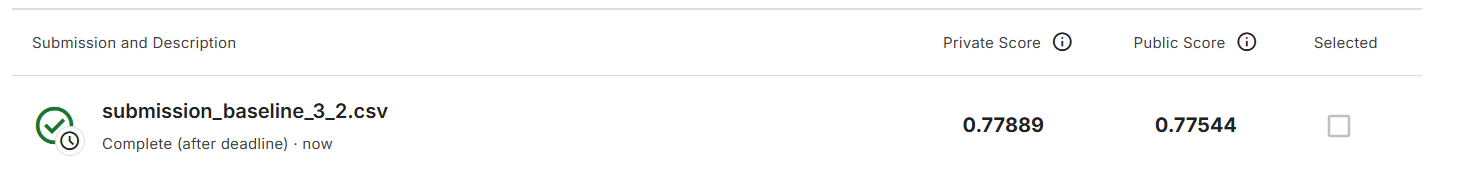

Соединим эти два результата 

In [8]:
required_cols_demo = ['days_birth', 'days_employed']
missing_cols_demo = [col for col in required_cols_demo if col not in common_cols]

if 'days_birth' in common_cols:
    X_train_full['age_years'] = -X_train_full['days_birth'] / 365.25
    df_test_processed['age_years'] = -df_test_processed['days_birth'] / 365.25

if 'days_employed' in common_cols and 'days_birth' in common_cols:
    X_train_full['employment_to_age_ratio'] = X_train_full['days_employed'] / X_train_full['days_birth']
    df_test_processed['employment_to_age_ratio'] = df_test_processed['days_employed'] / df_test_processed['days_birth']

required_cols_fin = ['amt_credit', 'amt_income_total', 'amt_annuity']
missing_cols_fin = [col for col in required_cols_fin if col not in common_cols]

if 'amt_income_total' in common_cols and X_train_full['amt_income_total'].notna().any():
    X_train_full['credit_to_income'] = X_train_full['amt_credit'] / X_train_full['amt_income_total']
    df_test_processed['credit_to_income'] = df_test_processed['amt_credit'] / df_test_processed['amt_income_total']

if 'amt_annuity' in common_cols and 'amt_income_total' in common_cols and X_train_full['amt_income_total'].notna().any():
    X_train_full['annuity_to_income'] = X_train_full['amt_annuity'] / X_train_full['amt_income_total']
    df_test_processed['annuity_to_income'] = df_test_processed['amt_annuity'] / df_test_processed['amt_income_total']

X_train_full = X_train_full.fillna(0)
df_test_processed = df_test_processed.fillna(0)

C:\Users\klmv0\AppData\Local\Temp\ipykernel_2792\429886259.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_train_full['age_years'] = -X_train_full['days_birth'] / 365.25
C:\Users\klmv0\AppData\Local\Temp\ipykernel_2792\429886259.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_test_processed['age_years'] = -df_test_processed['days_birth'] / 365.25
C:\Users\klmv0\AppData\Local\Temp\ipykernel_2792\429886259.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` m

In [9]:
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full)

cat_model_optimal = CatBoostClassifier(
    iterations=1000,     
    learning_rate=0.03,       
    depth=7,          
    auto_class_weights='SqrtBalanced',
    random_state=42,
    l2_leaf_reg=2,  
    eval_metric='AUC',
    loss_function='Logloss',
    verbose=100)

cat_model_optimal.fit(X_train, y_train, eval_set=(X_val, y_val), cat_features=cat_cols)

0:	test: 0.6978328	best: 0.6978328 (0)	total: 4.37s	remaining: 1h 12m 42s
100:	test: 0.7632548	best: 0.7632548 (100)	total: 1m 54s	remaining: 16m 55s
200:	test: 0.7733274	best: 0.7733274 (200)	total: 3m 41s	remaining: 14m 40s
300:	test: 0.7777804	best: 0.7777804 (300)	total: 5m 31s	remaining: 12m 49s
400:	test: 0.7806080	best: 0.7806080 (400)	total: 9m 5s	remaining: 13m 34s
500:	test: 0.7831343	best: 0.7831343 (500)	total: 11m 39s	remaining: 11m 36s
600:	test: 0.7848097	best: 0.7848216 (599)	total: 13m 55s	remaining: 9m 14s
700:	test: 0.7857142	best: 0.7857142 (700)	total: 16m 3s	remaining: 6m 51s
800:	test: 0.7865795	best: 0.7865795 (800)	total: 18m 8s	remaining: 4m 30s
900:	test: 0.7868441	best: 0.7868569 (897)	total: 20m 14s	remaining: 2m 13s
999:	test: 0.7871731	best: 0.7871731 (999)	total: 22m 14s	remaining: 0us

bestTest = 0.7871730505
bestIteration = 999



In [10]:
y_val_pred_proba = cat_model_optimal.predict_proba(X_val)[:, 1]
val_metrics = {
    'ROC-AUC': roc_auc_score(y_val, y_val_pred_proba),
    'Accuracy': accuracy_score(y_val, y_val_pred_proba > 0.5),
    'Precision': precision_score(y_val, y_val_pred_proba > 0.5),
    'Recall': recall_score(y_val, y_val_pred_proba > 0.5),
    'F1-Score': f1_score(y_val, y_val_pred_proba > 0.5)
}
for metric, value in val_metrics.items():
    print(f'Validation {metric}: {value:.4f}')

Validation ROC-AUC: 0.7872
Validation Accuracy: 0.9043
Validation Precision: 0.3685
Validation Recall: 0.2598
Validation F1-Score: 0.3047


In [11]:
test_pred_proba = cat_model_optimal.predict_proba(df_test_processed)[:, 1]
submission = pd.DataFrame({
    'sk_id_curr': df_test['sk_id_curr'],
    'target': test_pred_proba
})
submission.to_csv('submission_baseline_3_3.csv', index=False)

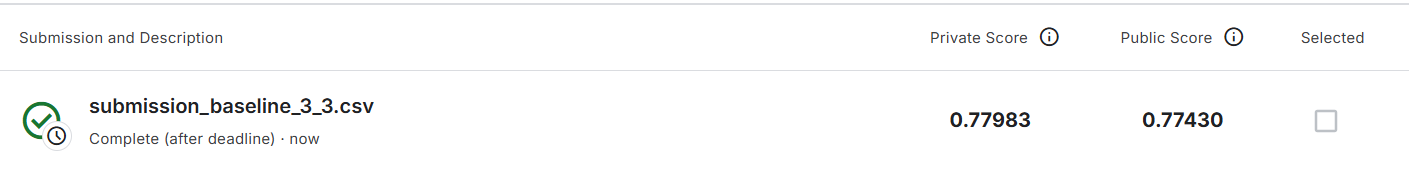